[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanglab-broad/FuseMap/blob/main/docs/notebooks/12_cross_species_marmoset.ipynb)

In [ ]:
# Requires a Python 3.9-3.11 runtime. For local setup, see docs/install.rst.
import sys
if not (3, 9) <= sys.version_info[:2] < (3, 12):
    raise RuntimeError("FuseMap requires Python 3.9-3.11. Select a compatible runtime or use the local setup.")
if "google.colab" in sys.modules:
    %pip install -q "fusemap[tutorials]"


# FuseMap Tutorial 12: Cross-species mapping — marmoset onto the mouse molCCF

This example maps a STARmap marmoset (*Callithrix jacchus*) forebrain/striatum
section onto the pretrained mouse reference, then compares transferred labels
with spatial domains computed from the marmoset data. Reference parameters stay
frozen while query-specific encoders/decoders and new gene embeddings are trained.

The saved example has **179,741 cells and 461 genes** before mapping QC. Matching
uses shared uppercase **gene symbols**, not a curated one-to-one ortholog table:
414 symbols occur in the reference vocabulary and 47 are treated as new genes.
Missing symbols do not establish absence of a mouse ortholog.

1. Compute an exploratory spatial-domain clustering from the query data.
2. Map the section with `fusemap.map_to_reference`.
3. Transfer mouse main tissue-region and cell-type labels.
4. Inspect concordance, mixed domains and anatomically unexpected predictions.

**Data access:** the manuscript states that these marmoset data are available
from the corresponding authors upon reasonable request. After obtaining the
file, place it at `tutorial12_data/marmoset_striatum.h5ad`. This notebook does
not provide a public data download. The [molCCF reference model](https://drive.google.com/drive/folders/1auybpmekWuW_G-7YPloJr-B96qiT1nFS)
is downloaded separately.

This example uses exploratory domains and main labels; it is not an exact
reproduction of the 10 annotated regions / 14 transferred labels reported in
Extended Data Fig. 9.


In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
import pickle
import numpy as np
import pandas as pd
import torch
import scanpy as sc
import matplotlib.pyplot as plt

## 1. Prepare the marmoset section and download the reference

Obtain the query data from the corresponding authors as described above. The
cell below checks the local file before downloading the molCCF reference used
in Tutorial 5. It checks an expected model file so an empty or incomplete
`molCCF/` directory is not treated as a completed download.


In [ ]:
from pathlib import Path
import gdown

query_file = Path("./tutorial12_data/marmoset_striatum.h5ad")
if not query_file.is_file():
    raise FileNotFoundError(
        "Marmoset data are available from the corresponding authors upon reasonable "
        "request (see the manuscript Data availability statement). After obtaining "
        "the data, place marmoset_striatum.h5ad in ./tutorial12_data/."
    )
if not Path("./molCCF/ad_gene_embedding.h5ad").is_file():
    gdown.download_folder(id="1auybpmekWuW_G-7YPloJr-B96qiT1nFS", output="./molCCF", quiet=False)


## 2. Inspect the marmoset section

Spatial coordinates are already in `obs['x']/obs['y']` (the only other `obs` column, `area`, is
the per-cell segmentation area in pixels — a QC covariate, not an annotation). All 461 gene
symbols are uppercase, which is exactly what the molCCF vocabulary expects.

AnnData object with n_obs × n_vars = 179741 × 461
    obs: 'area', 'x', 'y'
First genes: ['ABCB4', 'ABI3BP', 'ACTA2', 'ADAMTS3', 'ADARB2', 'ADGRG6', 'ADORA2A', 'ADRA1D']
All symbols uppercase: True


414/461 marmoset genes are in the molCCF gene vocabulary


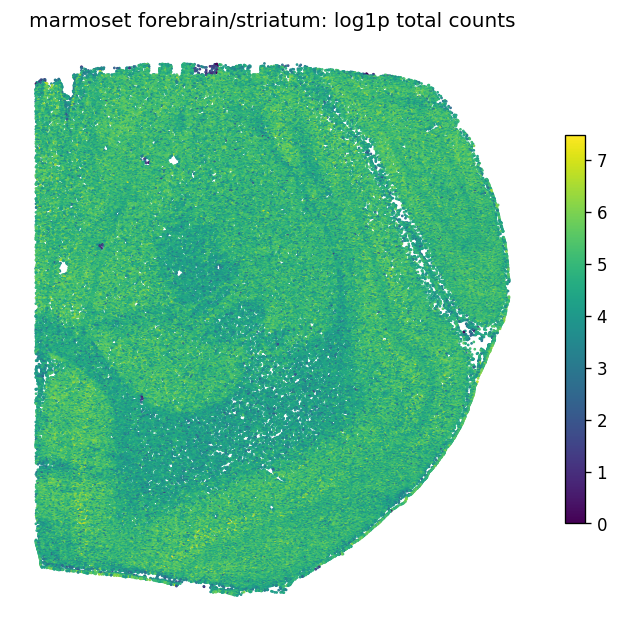

In [4]:
ad_marmoset = sc.read_h5ad("./tutorial12_data/marmoset_striatum.h5ad")
print(ad_marmoset)
print("First genes:", list(ad_marmoset.var_names[:8]))
print("All symbols uppercase:", all(g == g.upper() for g in ad_marmoset.var_names))

# ortholog matching by shared symbol: how many marmoset genes are in the molCCF vocabulary?
ref_genes = set(sc.read_h5ad("./molCCF/ad_gene_embedding.h5ad").obs_names)
n_shared = sum(g in ref_genes for g in ad_marmoset.var_names)
print(f"{n_shared}/{ad_marmoset.n_vars} marmoset genes are in the molCCF gene vocabulary")

counts = np.asarray(ad_marmoset.X.sum(1)).ravel()
fig, ax = plt.subplots(figsize=(7, 7), dpi=120)
sca = ax.scatter(ad_marmoset.obs["x"], ad_marmoset.obs["y"], c=np.log1p(counts),
                 s=0.4, cmap="viridis", rasterized=True)
ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
ax.set_title("marmoset forebrain/striatum: log1p total counts")
plt.colorbar(sca, ax=ax, shrink=0.6)
plt.show()

## 3. The marmoset's own unsupervised view

Before any cross-species transfer, we build the comparison target: an **unsupervised spatial
domain annotation** derived purely from the marmoset data itself, an exploratory comparison that is not the paper's finalized anatomical annotation. We average each cell's PCA expression profile
over its 30 nearest spatial neighbors (a molecular "niche" profile) and Leiden-cluster the
smoothed profiles. No mouse information enters this step.

39 unsupervised domains
marmoset_domain
domain 0     13731
domain 1     13412
domain 2     10940
domain 3     10217
domain 4      7651
domain 5      7395
domain 6      7336
domain 7      7248
domain 8      7206
domain 9      6527
domain 10     6065
domain 11     6058
domain 12     6002
domain 13     5710
domain 14     5268
domain 15     4947
domain 16     4739
domain 17     4666
domain 18     4462
domain 19     3683
domain 20     3367
domain 21     3327
domain 22     3285
domain 23     3124
domain 24     3004
domain 25     2903
domain 26     2856
domain 27     2728
domain 28     2716
domain 29     2538
domain 30     1949
domain 31     1665
domain 32     1276
domain 33      890
domain 34      613
domain 35      123
domain 36       42
domain 37       41
domain 38       31
Name: count, dtype: int64


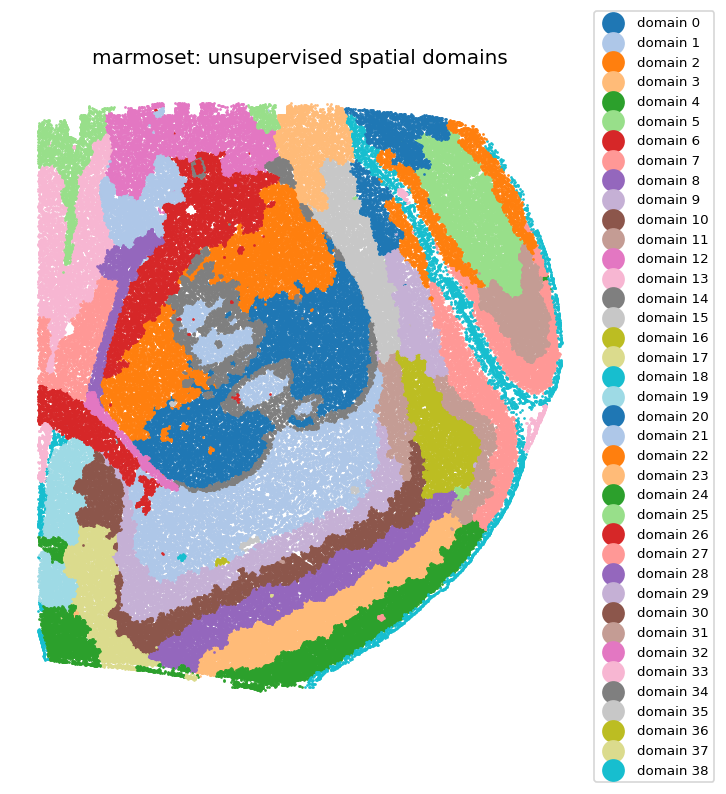

In [5]:
domain_csv = "./tutorial12_data/marmoset_domains.csv"
if os.path.exists(domain_csv):
    dom = pd.read_csv(domain_csv)["marmoset_domain"].astype(str)
    assert len(dom) == ad_marmoset.n_obs
    ad_marmoset.obs["marmoset_domain"] = dom.values
else:
    from sklearn.neighbors import NearestNeighbors

    tmp = ad_marmoset.copy()
    sc.pp.normalize_total(tmp, target_sum=1e4)
    sc.pp.log1p(tmp)
    sc.pp.scale(tmp, max_value=10)
    sc.tl.pca(tmp, n_comps=30)

    # smooth PCs over the 30 nearest spatial neighbors -> niche profiles
    xy = tmp.obs[["x", "y"]].to_numpy(dtype=float)
    knn_idx = NearestNeighbors(n_neighbors=30).fit(xy).kneighbors(xy)[1]
    tmp.obsm["X_niche"] = tmp.obsm["X_pca"][knn_idx].mean(axis=1)

    sc.pp.neighbors(tmp, use_rep="X_niche", n_neighbors=15)
    sc.tl.leiden(tmp, resolution=0.5, n_iterations=2, key_added="marmoset_domain")
    ad_marmoset.obs["marmoset_domain"] = ("domain " + tmp.obs["marmoset_domain"].astype(str)).values
    pd.DataFrame({"marmoset_domain": ad_marmoset.obs["marmoset_domain"].values}).to_csv(domain_csv, index=False)

domains = sorted(ad_marmoset.obs["marmoset_domain"].unique(), key=lambda s: int(s.split()[-1]))
print(f"{len(domains)} unsupervised domains")
print(ad_marmoset.obs["marmoset_domain"].value_counts())

cmap20 = plt.get_cmap("tab20")
dom_pal = {d: cmap20(i % 20) for i, d in enumerate(domains)}
fig, ax = plt.subplots(figsize=(8, 7), dpi=120)
for d in domains:
    m = (ad_marmoset.obs["marmoset_domain"] == d).values
    ax.scatter(ad_marmoset.obs["x"][m], ad_marmoset.obs["y"][m], s=0.4,
               c=[dom_pal[d]], label=d, rasterized=True)
ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
ax.set_title("marmoset: unsupervised spatial domains")
ax.legend(markerscale=20, fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.show()

## 4. Map to molCCF — one call

Identical to Tutorial 5: `fusemap.map_to_reference` projects every `.h5ad` in the folder into
the molCCF latent space by training query-specific encoders/decoders and embeddings of new genes;
the reference model itself is not retrained. Results land in one subdirectory per input file.

**Runtime note:** this section has ~180k cells, so expect roughly **1-3 hours** on a single
GPU; runtime depends on the hardware. The saved output below resumed an
already completed pretraining snapshot, so its 0.3-minute timing is not a
fresh-training benchmark. Use a new output directory to measure a fresh run.

In [6]:
import time
import fusemap

pretrain_model_path = "./molCCF"
t0 = time.time()
fusemap.map_to_reference("./tutorial12_data", "./output_tutorial12", pretrain_model_path)
print(f"mapping wall time: {(time.time() - t0) / 60:.1f} min")

output_dir = "./output_tutorial12/marmoset_striatum.h5ad" 

2026-09-10 13:19:07,090 - INFO - 

---------------------------------- Preprocess adata ----------------------------------



2026-09-10 13:19:12,873 - INFO - 

---------------------------------- Construct graph adata ----------------------------------



2026-09-10 13:19:14,642 - INFO - 

---------------------------------- Process graph adata ----------------------------------



2026-09-10 13:19:15,797 - INFO - 

number of genes in each section:[461], Number of all genes: 461



2026-09-10 13:19:22,525 - INFO - 

pretrain gene number:414, new gene number:47



...

2026-09-10 13:19:22,898 - INFO - [FuseMap loader] parallel batch preparation ENABLED: num_workers=2, prefetch_factor=4, pin_memory=True, persistent_workers=True.


2026-09-10 13:19:22,899 - INFO - [FuseMap loader] atlas 0: dense CPU feature cache ENABLED (179576 x 461 = 0.308 GB < 2.0 GB limit); per-batch slicing uses torch row indexing.


2026-09-10 13:19:23,126 - INFO - [FuseMap loader] parallel batch preparation ENABLED: num_workers=2, prefetch_factor=4, pin_memory=True, persistent_workers=True.


2026-09-10 13:19:23,132 - INFO - 

---------------------------------- Finish ----------------------------------



mapping wall time: 0.3 min


## 5. Transfer mouse labels onto the marmoset cells

Same mechanics as Tutorial 5: the molCCF folder ships pretrained `NNTransfer` classifiers
(under `molCCF/transfer/`) that predict the **main cell type** and **main tissue region** from
the 64-dimensional latent embedding. We apply them to the mapped marmoset embeddings — every
marmoset cell receives a mouse atlas label through the shared latent space.

In [7]:
from fusemap.utils import NNTransferTrain, NNTransfer, NNTransferPredictWithUncertainty
from torch.utils.data import DataLoader, TensorDataset


def transfer_annotation(molccf_path, save_dir):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    ### transfer cell type
    ad_embed = sc.read_h5ad(os.path.join(save_dir, 'ad_celltype_embedding.h5ad'))
    if 'fusemap_celltype' not in ad_embed.obs.columns:
        with open(os.path.join(molccf_path, 'transfer', 'le_gt_cell_type_main_STARmap.pkl'), 'rb') as file:
            le_gt_cell_type_main_STARmap = pickle.load(file)

        NNmodel = NNTransfer(input_dim=64, output_dim=len(le_gt_cell_type_main_STARmap))
        NNmodel.load_state_dict(torch.load(molccf_path + "/transfer/NNtransfer_cell_type_main_STARmap.pt"))

        dataset = TensorDataset(torch.Tensor(ad_embed.X))
        dataloader = DataLoader(dataset, batch_size=256, shuffle=False)

        NNmodel.to(device)
        NNmodel.eval()
        all_predictions = []
        with torch.no_grad():
            for inputs in dataloader:
                inputs = inputs[0].to(device)
                outputs = NNmodel(inputs)
                _, predicted = torch.max(outputs, 1)
                all_predictions.extend(predicted.detach().cpu().numpy())
        ad_embed.obs['fusemap_celltype'] = [le_gt_cell_type_main_STARmap[i] for i in all_predictions]
        ad_embed.write_h5ad(save_dir + "/ad_celltype_embedding.h5ad")

    ### transfer tissue niche
    ad_embed = sc.read_h5ad(save_dir + "/ad_tissueregion_embedding.h5ad")
    if 'fusemap_tissueregion' not in ad_embed.obs.columns:
        with open(os.path.join(molccf_path, 'transfer', 'le_gt_tissue_region_main_STARmap.pkl'), 'rb') as file:
            le_gt_tissue_region_main_STARmap = pickle.load(file)

        NNmodel = NNTransfer(input_dim=64, output_dim=len(le_gt_tissue_region_main_STARmap))
        NNmodel.load_state_dict(torch.load(molccf_path + "/transfer/NNtransfer_tissue_region_main_STARmap.pt"))

        dataset = TensorDataset(torch.Tensor(ad_embed.X))
        dataloader = DataLoader(dataset, batch_size=256, shuffle=False)

        NNmodel.to(device)
        NNmodel.eval()
        all_predictions = []
        with torch.no_grad():
            for inputs in dataloader:
                inputs = inputs[0].to(device)
                outputs = NNmodel(inputs)
                _, predicted = torch.max(outputs, 1)
                all_predictions.extend(predicted.detach().cpu().numpy())
        ad_embed.obs['fusemap_tissueregion'] = [le_gt_tissue_region_main_STARmap[i] for i in all_predictions]
        ad_embed.write_h5ad(save_dir + "/ad_tissueregion_embedding.h5ad")


transfer_annotation(pretrain_model_path, output_dir)

## 6. Compare query domains and transferred mouse regions

The two spatial plots and cross-tabulation show where the query domains agree
with coarse mouse atlas labels and where they do not. A concentrated row suggests
label concordance; a mixed row or unexpected brain-region label needs closer
inspection. A forced-choice classifier can assign a mouse label even when no
suitable counterpart is represented in the reference.


mapped 179576 of 179741 marmoset cells (165 dropped during QC)
transferred mouse regions: ['CB_1', 'CB_2', 'CTX_1', 'CTX_2', 'DG', 'ENTm', 'FbTrt', 'HPF_CA', 'HY', 'Hbl_VS', 'L1_HPFmo_Mngs', 'LSX_HY_MB_HB', 'MYdp', 'OB_1', 'OB_2', 'STR', 'TH']


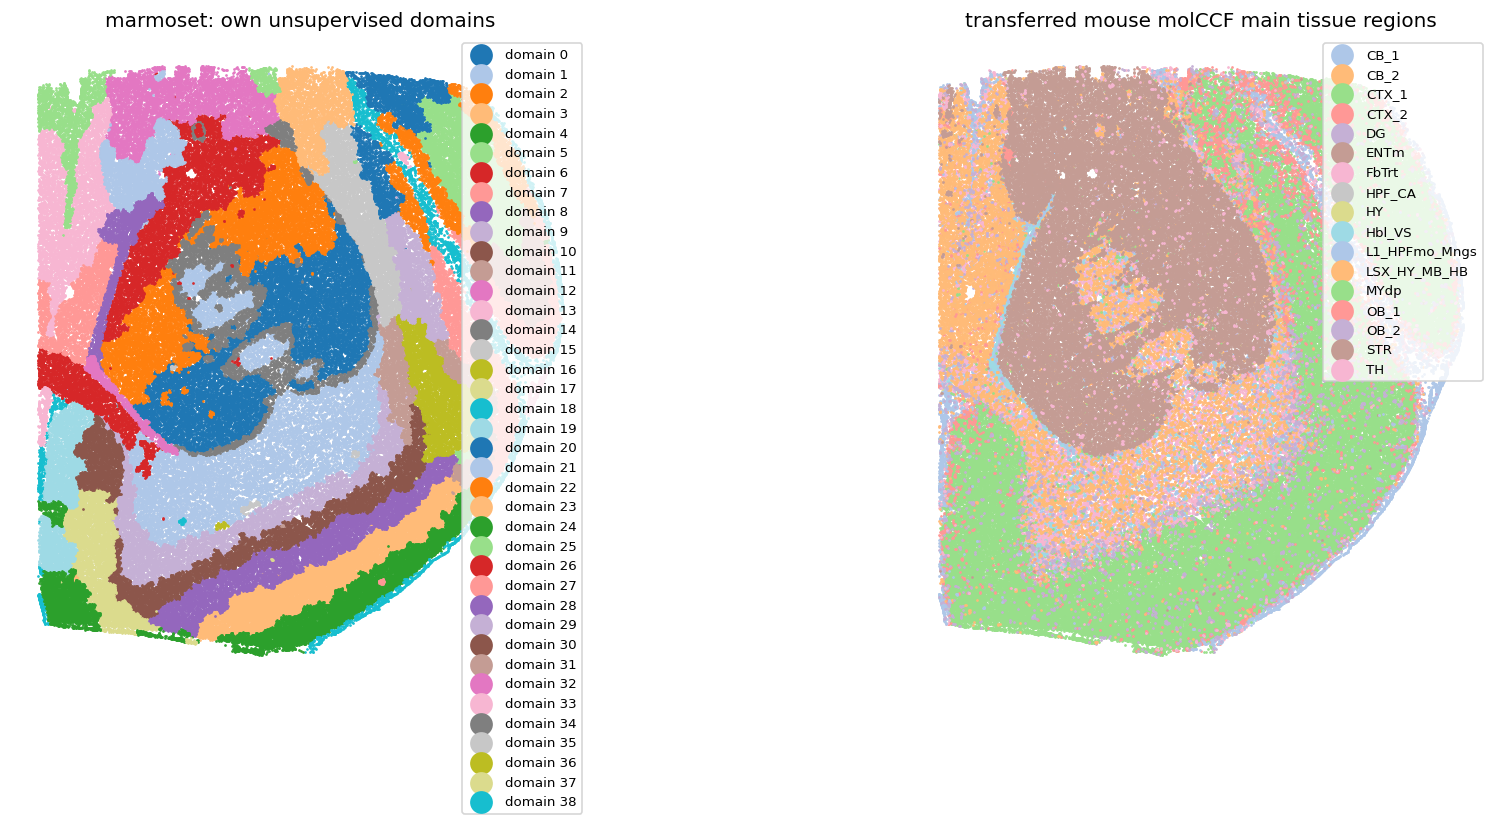

In [8]:
ad_region = sc.read_h5ad(os.path.join(output_dir, "ad_tissueregion_embedding.h5ad"))

# FuseMap applies QC during mapping, so the mapped output can be slightly smaller
# than the input. Mapped cells are a subset (same names) — align the marmoset's own
# domain labels to them by cell name.
n_drop = ad_marmoset.n_obs - ad_region.n_obs
print(f"mapped {ad_region.n_obs} of {ad_marmoset.n_obs} marmoset cells "
      f"({n_drop} dropped during QC)")
marm_dom = (ad_marmoset.obs["marmoset_domain"]
            .reindex(ad_region.obs_names).astype(str).values)

x_out = pd.to_numeric(ad_region.obs["x"], errors="coerce").to_numpy()
y_out = pd.to_numeric(ad_region.obs["y"], errors="coerce").to_numpy()
regions_pred = ad_region.obs["fusemap_tissueregion"].astype(str).values
region_names = sorted(set(regions_pred))
print("transferred mouse regions:", region_names)

reg_pal = {r: cmap20((i * 2 + 1) % 20) for i, r in enumerate(region_names)}
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=120)
for d_ in domains:
    mask = marm_dom == d_
    axes[0].scatter(x_out[mask], y_out[mask], s=0.4, c=[dom_pal[d_]], label=d_, rasterized=True)
axes[0].set_title("marmoset: own unsupervised domains")
for rname in region_names:
    mask = regions_pred == rname
    axes[1].scatter(x_out[mask], y_out[mask], s=0.4, c=[reg_pal[rname]], label=rname, rasterized=True)
axes[1].set_title("transferred mouse molCCF main tissue regions")
for ax in axes:
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
    ax.legend(markerscale=20, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

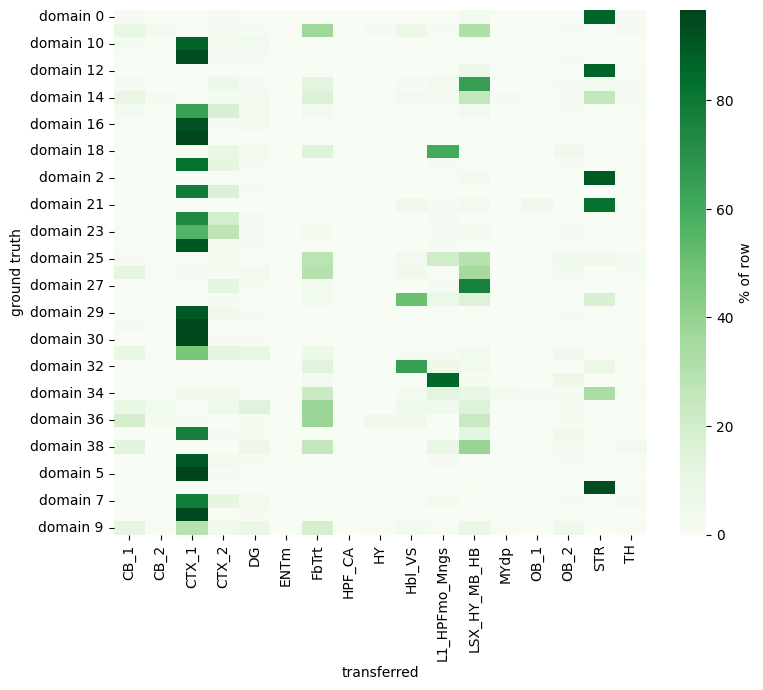

,n cells,majority transferred region,fraction
domain 0,13725,STR,0.87
domain 1,13397,FbTrt,0.37
domain 2,10939,STR,0.90
domain 3,10215,CTX_1,0.95
domain 4,7649,CTX_1,0.90
domain 5,7393,CTX_1,0.97
domain 6,7332,STR,0.93
domain 7,7248,CTX_1,0.78
domain 8,7206,CTX_1,0.95
domain 9,6524,CTX_1,0.30


In [9]:
import fusemap.pl

fig = fusemap.pl.transfer_heatmap(gt=marm_dom, pred=regions_pred, figsize=(8, 7))
plt.show()

# per-domain majority transferred label
ct = pd.crosstab(pd.Series(marm_dom, name="marmoset domain"),
                 pd.Series(regions_pred, name="transferred"), normalize="index")
summary = pd.DataFrame({
    "n cells": pd.Series(marm_dom).value_counts(),
    "majority transferred region": ct.idxmax(axis=1),
    "fraction": ct.max(axis=1).round(2),
}).sort_values("n cells", ascending=False)
summary

### Reading the heatmap

In the saved run, 179,576 of 179,741 cells remained after QC. The exploratory
clustering has **39 domains** and the transfer produced **17 main region labels**.
Domains 0, 2 and 6 predominantly map to STR (87%, 90% and 93%); domains 3, 5 and 8
predominantly map to CTX_1 (95%, 97% and 95%). These are coarse concordances.

Other rows are mixed: domain 1's largest fraction is FbTrt at 37%, and domain 14's
largest fraction is LSX_HY_MB_HB at 25%. Cerebellar labels (CB_1/CB_2) also appear
among predictions for this forebrain section. These are reasons to examine
confidence, measured markers, spatial boundaries and ortholog matching rather
than accept every assigned label. Row maxima are **not annotation accuracy**:
the unsupervised query domains are not independently validated ground truth.


fusemap_celltype
Telencephalon projecting excitatory neurons    36831
Telencephalon projecting inhibitory neurons    19318
Astrocytes                                     16554
Hindbrain neurons/Spinal cord neurons          10462
Telencephalon inhibitory interneurons          10406
Cholinergic and monoaminergic neurons          10280
Ependymal cells                                 7435
Microglia                                       6851
Oligodendrocytes                                5864
Olfactory ensheathing cells                     5706
Name: count, dtype: int64


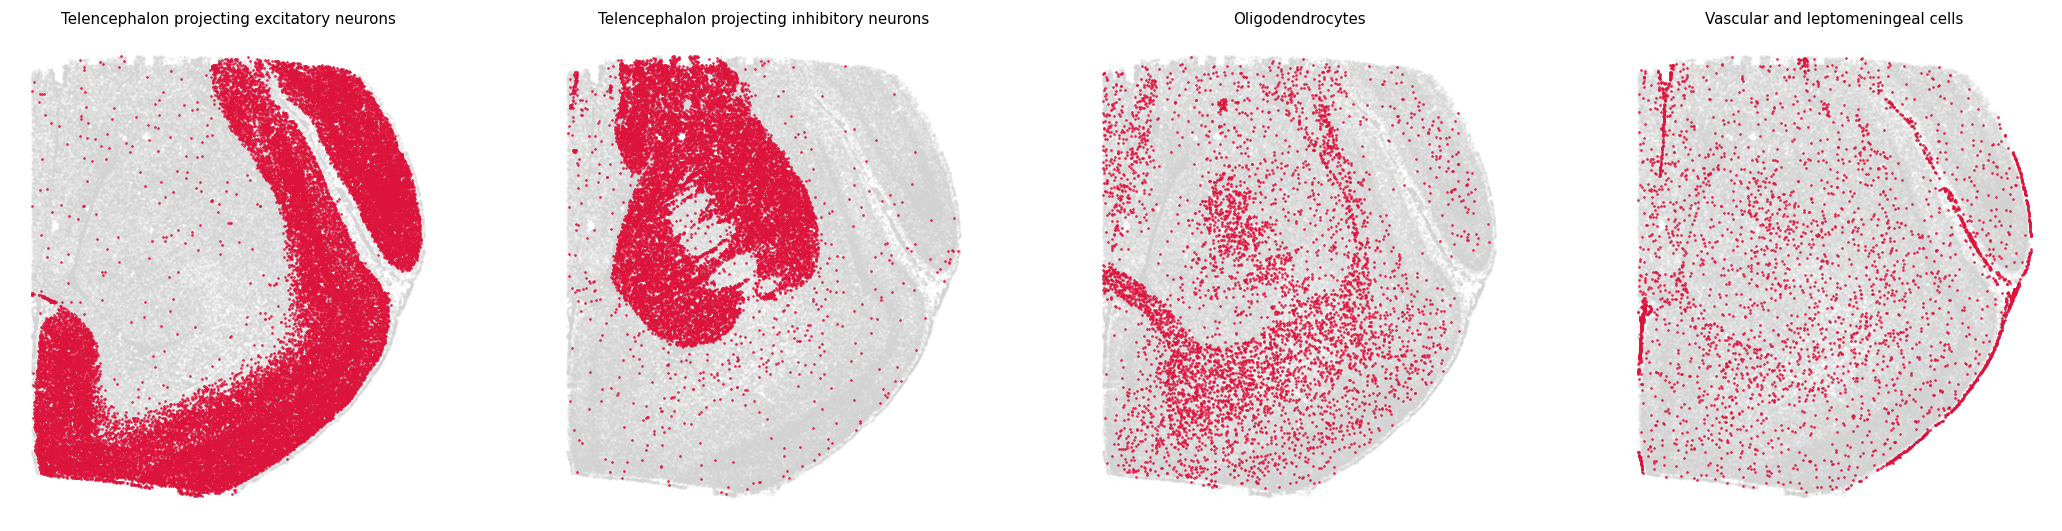

In [10]:
ad_ct = sc.read_h5ad(os.path.join(output_dir, "ad_celltype_embedding.h5ad"))
print(ad_ct.obs["fusemap_celltype"].value_counts().head(10))

show_types = [t for t in [
    "Telencephalon projecting excitatory neurons",
    "Telencephalon projecting inhibitory neurons",
    "Oligodendrocytes",
    "Vascular and leptomeningeal cells",
] if t in set(ad_ct.obs["fusemap_celltype"])]

fig, axes = plt.subplots(1, len(show_types), figsize=(4.5 * len(show_types), 4.5), dpi=120)
for ax, t in zip(np.atleast_1d(axes), show_types):
    m = (ad_ct.obs["fusemap_celltype"] == t).values
    ax.scatter(x_out[~m], y_out[~m], s=0.3, c="lightgray", alpha=0.2, rasterized=True)
    ax.scatter(x_out[m], y_out[m], s=0.3, c="crimson", rasterized=True)
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
    ax.set_title(t, fontsize=9)
plt.tight_layout()
plt.show()

## Interpretation and limits

The saved example shows concordance for several striatal and cortical domains,
alongside mixed domains and anatomically unexpected assignments. It demonstrates
the mapping workflow and the need to review cross-species transfer results;
it does not by itself validate all transferred anatomy or establish conservation.

Shared uppercase symbols are a practical matching rule, not a curated orthology
map. The 47 symbols absent from the model vocabulary are learned as new genes;
they should not be described as lacking mouse counterparts. Main-label transfer
also cannot resolve primate-specific subtypes without additional evidence.

See **Extended Data Fig. 9** and its methods for the manuscript's cross-species
analysis, which uses different annotation granularity and validation.
